# Feature Scaling

We discussed previously that the scale of the features is an important consideration when building machine learning models. Briefly:


### Feature magnitude matters because:

- The regression coefficients of linear models are directly influenced by the scale of the variable.
- Variables with bigger magnitude / larger value range dominate over those with smaller magnitude / value range
- Gradient descent converges faster when features are on similar scales
- Feature scaling helps decrease the time to find support vectors for SVMs
- Euclidean distances are sensitive to feature magnitude.
- Some algorithms, like PCA require the features to be centered at 0.


### The machine learning models affected by the feature scale are:

- Linear and Logistic Regression
- Neural Networks
- Support Vector Machines
- KNN
- K-means clustering
- Linear Discriminant Analysis (LDA)
- Principal Component Analysis (PCA)


### Feature Scaling

**Feature scaling** refers to the methods or techniques used to normalize the range of independent variables in our data, or in other words, the methods to set the feature value range within a similar scale. Feature scaling is generally the last step in the data preprocessing pipeline, performed **just before training the machine learning algorithms**.

There are several Feature Scaling techniques, which we will discuss throughout this section:

- Standardisation
- Mean normalisation
- Scaling to minimum and maximum values - MinMaxScaling
- Scaling to maximum value - MaxAbsScaling
- Scaling to quantiles and median - RobustScaling
- Normalization to vector unit length

=================================================================

## Standardisation


Standardisation involves centering the variable at zero, and standardising the variance to 1. The procedure involves subtracting the mean of each observation and then dividing by the standard deviation:

**z = (x - x_mean) /  std**

The result of the above transformation is **z**, which is called the z-score, and represents how many standard deviations a given observation deviates from the mean. A z-score specifies the location of the observation within a distribution (in numbers of standard deviations respect to the mean of the distribution). The sign of the z-score (+ or - ) indicates whether the observation is above (+) or below ( - ) the mean.

The shape of a standardised (or z-scored normalised) distribution will be identical to the original distribution of the variable. If the original distribution is normal, then the standardised distribution will be normal. But, if the original distribution is skewed, then the standardised distribution of the variable will also be skewed. In other words, **standardising a variable does not normalize the distribution of the data** and if this is the desired outcome, we should implement any of the techniques discussed in section 7 of the course.

In a nutshell, standardisation:

- centers the mean at 0
- scales the variance at 1
- preserves the shape of the original distribution
- the minimum and maximum values of the different variables may vary
- preserves outliers

Good for algorithms that require features centered at zero.

=================================================================

## Scaling to Minimum and Maximum values - MinMaxScaling

Minimum and maximum scaling squeezes the values between 0 and 1. It subtracts the minimum value from all the observations, and then divides it by the value range:

X_scaled = (X - X.min / (X.max - X.min)


The result of the above transformation is a distribution which values vary within the range of 0 to 1. But the mean is not centered at zero and the standard deviation varies across variables. The shape of a min-max scaled distribution will be similar to the original variable. This scaling technique is also sensitive to outliers.

In a nutshell, MinMaxScaling:

- the minimum and maximum values are 0 and 1.
- does not center the mean at 0
- variance varies across variables
- sensitive outliers

=================================================================

## Mean Normalisation


Mean normalisation involves centering the variable at zero, and re-scaling to the value range. The procedure involves subtracting the mean of each observation and then dividing by difference between the minimum and maximum value:

**x_scaled = (x - x_mean) / ( x_max - x_min)**


The result of the above transformation is a distribution that is centered at 0, and its minimum and maximum values are within the range of -1 to 1. The shape of a mean normalised distribution will be similar to the original distribution.

In a nutshell, mean normalisation:

- centers the mean at 0
- variance will be different
- the minimum and maximum values are squeezed between -1 and 1
- preserves outliers

Good for algorithms that require features centered at zero.

=================================================================

## Scaling to maximum value - MaxAbsScaling

Maximum absolute scaling scales the data to its absolute maximum value:

X_scaled = X / abs(X.max)

The result of the above transformation is a distribution which values vary within the range of -1 to 1. But the mean is not centered at zero and the standard deviation varies across variables.

Scikit-learn suggests that this transformer is meant for data that is centered at zero, and for sparse data.

=================================================================

## Scaling to quantiles and median - RobustScaling

In this procedure the median is removed from the observations and then they are scaled to the inter-quantile range (IQR). The IQR is the range between the 1st quartile (25th quantile) and the 3rd quartile (75th quantile).

X_scaled = X - X_median / ( X.quantile(0.75) - X.quantile(0.25) )

This robust scaling method produces more robust estimates for the center and range of the variable, and is recommended if the data shows outliers.
=================================================================

## Scaling to vector unit  length / unit norm

In this procedure we scale the components of a feature vector such that the complete vector has a length of 1 or, in other words a norm of 1. **Note** that this normalisation procedure normalises the **feature** vector, and not the **observation** vector. So we divide by the norm of the feature vector, observation per observation, across the different variables, and not by the norm of the **observation** vector, across observations for the same feature.

First, let me give you the formulas, and then I illustrate with an example.

### Scaling to unit norm, formulas

Scaling to unit norm is achieved by dividing each feature vector by either the Manhattan distance (l1 norm) or the Euclidean distance of the vector (l2 norm):

X_scaled_l1 = X / l1(X)

X_scaled_l2 = X / l2(X)


The **Manhattan distance** is given by the sum of the absolute components of the vector:

l1(X) = |x1| + |x2| + ... + |xn|


Whereas the **Euclidean distance** is given by the square root of the square sum of the component of the vector:

l2(X) = sqr( x1^2 + x2^2 + ... + xn^2 )


In the above example, x1 is variable 1, x2 variable 2, and xn variable n, and X is the data for 1 observation across variables (a row in other words).

**Note** as well that as the euclidean distance squares the values of the feature vector components, outliers have a heavier weight. With outliers, we may prefer to use l1 normalisation.


### Scaling to unit norm, examples

For example, if our data has 1 observations (1 row) and 3 variables:

- number of pets
- number of children
- age

The values for each variable for that single observation are 10, 15 and 20. Our vector X = [10, 15, 20]. Then:

l1(X) = 10 + 15 + 20 = 45

l2(X) = sqr( 10^2 + 15^2 + 20^2) = sqr( 100 + 225 + 400) = **26.9**

The euclidean distance is always smaller than the manhattan distance.


The normalised vector values are therefore:

X_scaled_l1 = [ 10/45, 15/45, 20/45 ]      =  [0.22, 0.33, 0.44]

X_scaled_l2 = [10/26.9, 15/26.9, 20/26.9 ] =  [0.37, 0.55, 0.74]


Scikit-learn recommends this scaling procedures for text classification or clustering. For example, they quote the dot product of two l2-normalized TF-IDF vectors is the cosine similarity of the vectors and is the base similarity metric for the Vector Space Model commonly used by the Information Retrieval community.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# dataset for the demo
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# the scalers
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import Normalizer

In [2]:
# load the California House price data from Scikit-learn

X, y = fetch_california_housing(return_X_y=True, as_frame=True)

In [3]:
# let's have a look at the main statistical parameters of the variables
# to get an idea of the feature magnitudes

X.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


The different variables present different value ranges, mean, max, min, standard deviations, etc. In other words, they show different magnitudes or scales.

Note that **the mean values are not centered at zero, and the standard deviations are not scaled to 1**.

When standardising the data set, we need to first identify the mean and standard deviation of the variables. These parameters need to be learned from the train set, stored, and then used to scale test and future data. Thus, we will first divide the data set into train and test, as we have done throughout the course.

In [4]:
# let's separate the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
)

# size
X_train.shape, X_test.shape

((14448, 8), (6192, 8))

## Standardisation

The StandardScaler from scikit-learn removes the mean and scales the data to unit variance. Plus, it learns and stores the parameters needed for scaling. Thus, it is top choice for this feature scaling technique.

On the downside, you can't select which variables to scale directly, it will scale the entire data set.

In [5]:
# standardisation: with the StandardScaler from sklearn

# set up the scaler
scaler = StandardScaler().set_output(transform="pandas")

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# the scaler stores the mean of the features, learned from train set

scaler.mean_

array([ 3.86666741e+00,  2.86187016e+01,  5.42340368e+00,  1.09477484e+00,
        1.42515732e+03,  3.04051776e+00,  3.56300934e+01, -1.19566647e+02])

In [7]:
# the scaler stores the standard deviation deviation of the features,
# learned from train set

scaler.scale_

array([1.89109236e+00, 1.25962585e+01, 2.28754018e+00, 4.52736275e-01,
       1.14954037e+03, 6.86792905e+00, 2.14004647e+00, 2.00651732e+00])

In [8]:
# let's check the stats of the scaled data:

X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.78,-2.19,-2.00,-1.68,-1.24,-0.33,-1.44,-2.38
25%,-0.69,-0.84,-0.42,-0.20,-0.56,-0.09,-0.79,-1.11
50%,-0.17,0.03,-0.08,-0.10,-0.23,-0.03,-0.64,0.54
75%,0.46,0.67,0.27,0.01,0.26,0.03,0.97,0.78
max,5.89,1.86,55.57,72.83,29.80,86.88,2.95,2.62


As expected, the mean of each variable is now centered at zero and the standard deviation is 1.

Note that the minimum and maximum values vary according to how spread the variable was to begin with and is highly influenced by the presence of outliers.

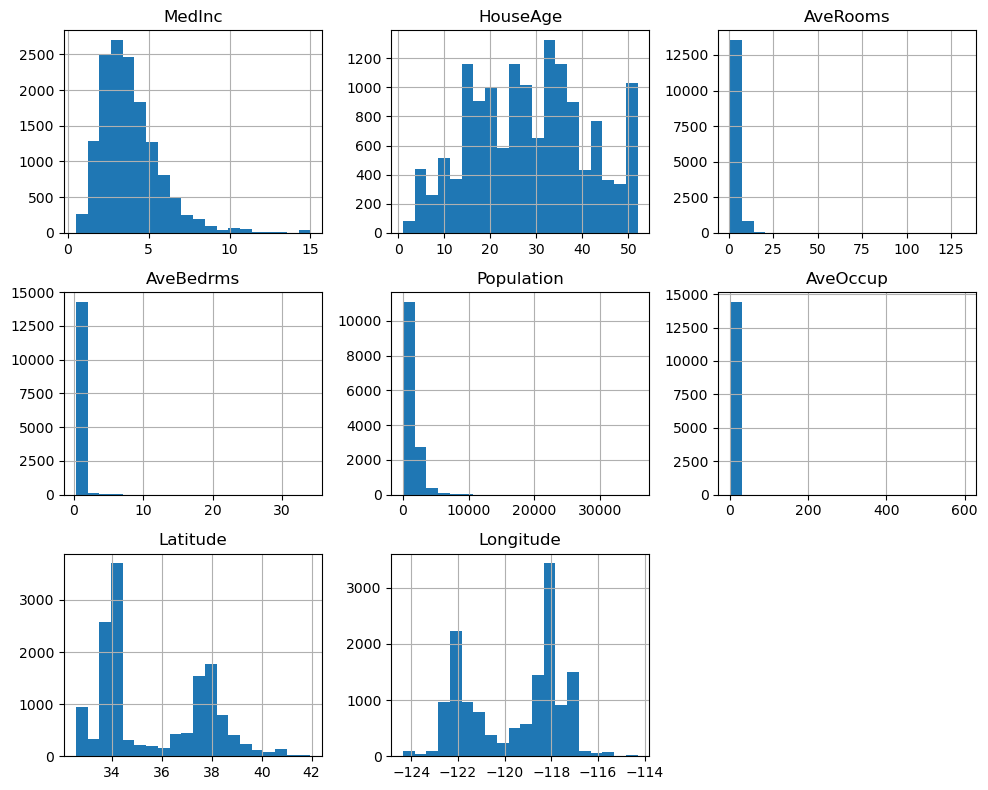

In [17]:
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(10, 8))
plt.tight_layout()
plt.show()

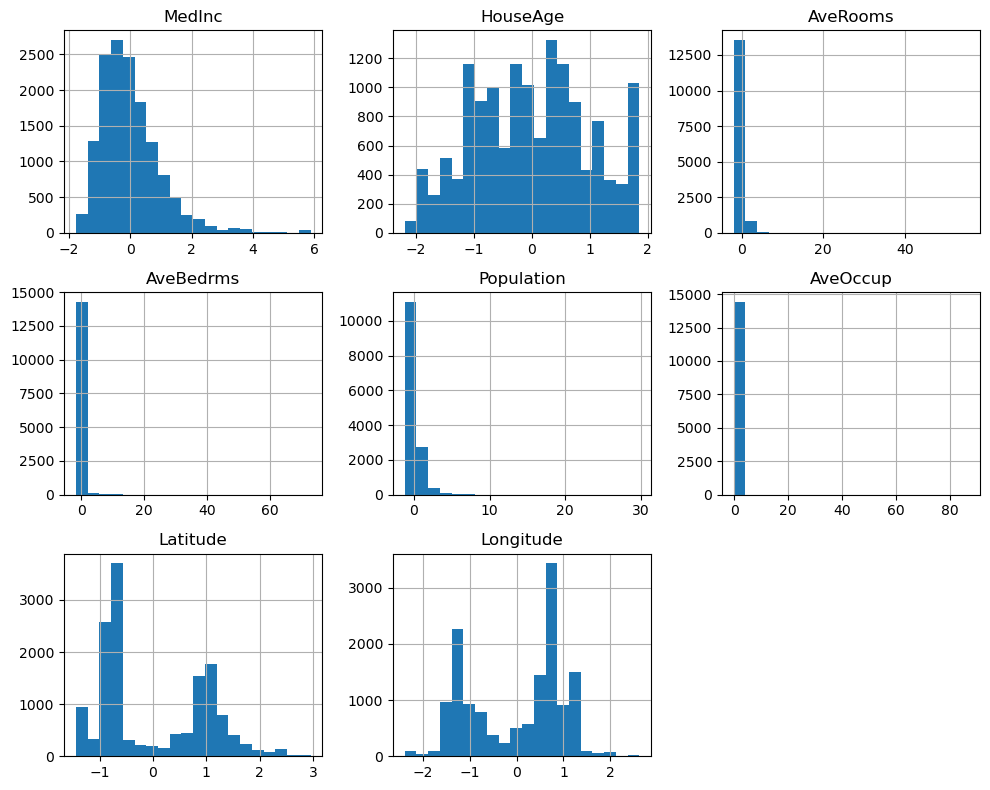

In [18]:
# Plot histograms of the features after scaling
X_train_scaled.hist(bins=20, figsize=(10, 8))
plt.tight_layout()
plt.show()

Note from the above plots how standardisation centered all the distributions at zero, but it preserved their original distribution.

## MinMaxScaling

The MinMaxScaler from scikit-learn subtracts the minimum value and re-scales the the value range, rendering the variable values between 0 and 1.

In [19]:
from sklearn.preprocessing import MinMaxScaler
# Set up the scaler with the option to return pandas DataFrame
scaler = MinMaxScaler().set_output(transform="pandas")
# Fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)
# Transform the train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# the scaler stores the maximum values of the features, learned from train set

scaler.data_max_

array([ 1.50001000e+01,  5.20000000e+01,  1.32533333e+02,  3.40666667e+01,
        3.56820000e+04,  5.99714286e+02,  4.19500000e+01, -1.14310000e+02])

In [21]:
# tthe scaler stores the minimum values of the features, learned from train set

scaler.min_

array([-3.44753865e-02, -1.96078431e-02, -6.42548386e-03, -9.88142292e-03,
       -8.40830741e-05, -1.25216147e-03, -3.45802338e+00,  1.23854582e+01])

In [22]:
# the scaler also stores the value range (max -  min)

scaler.data_range_

array([1.45002000e+01, 5.10000000e+01, 1.31687179e+02, 3.37333333e+01,
       3.56790000e+04, 5.98964286e+02, 9.41000000e+00, 1.00400000e+01])

In [23]:
# let's check the stats of the scaled data:

X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.23,0.54,0.03,0.02,0.04,0.00,0.33,0.48
std,0.13,0.25,0.02,0.01,0.03,0.01,0.23,0.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.14,0.33,0.03,0.02,0.02,0.00,0.15,0.25
50%,0.21,0.55,0.03,0.02,0.03,0.00,0.18,0.58
75%,0.29,0.71,0.04,0.02,0.05,0.00,0.55,0.63
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


As expected, the minimum and maximum values for all the variables are 0 and 1, respectively. The mean is not centered at zero, and the variance changes.

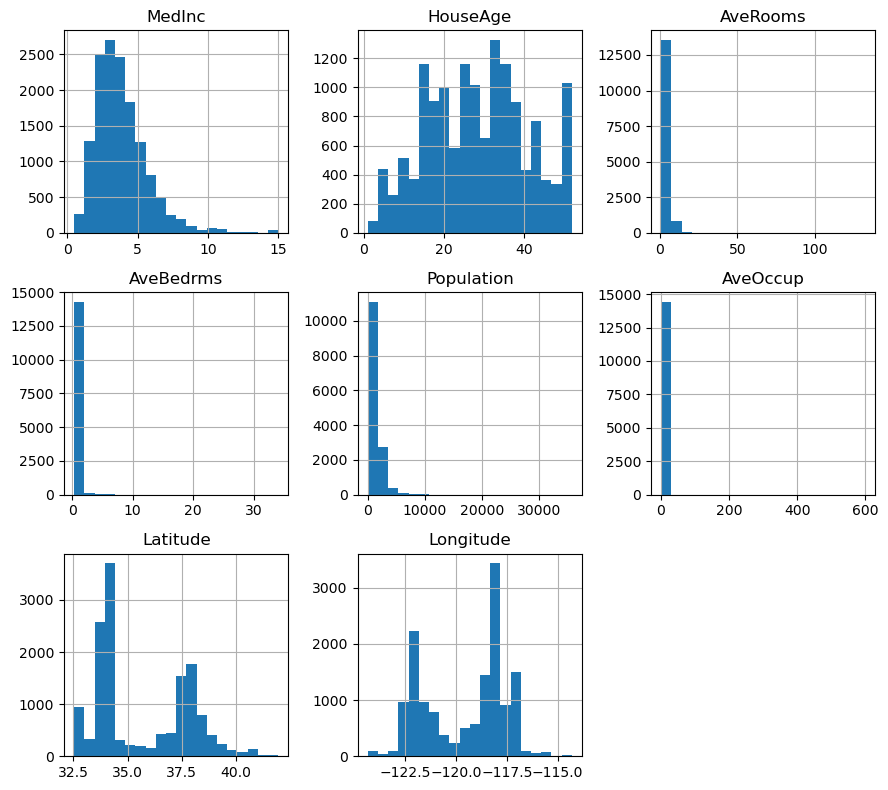

In [24]:
import matplotlib.pyplot as plt
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

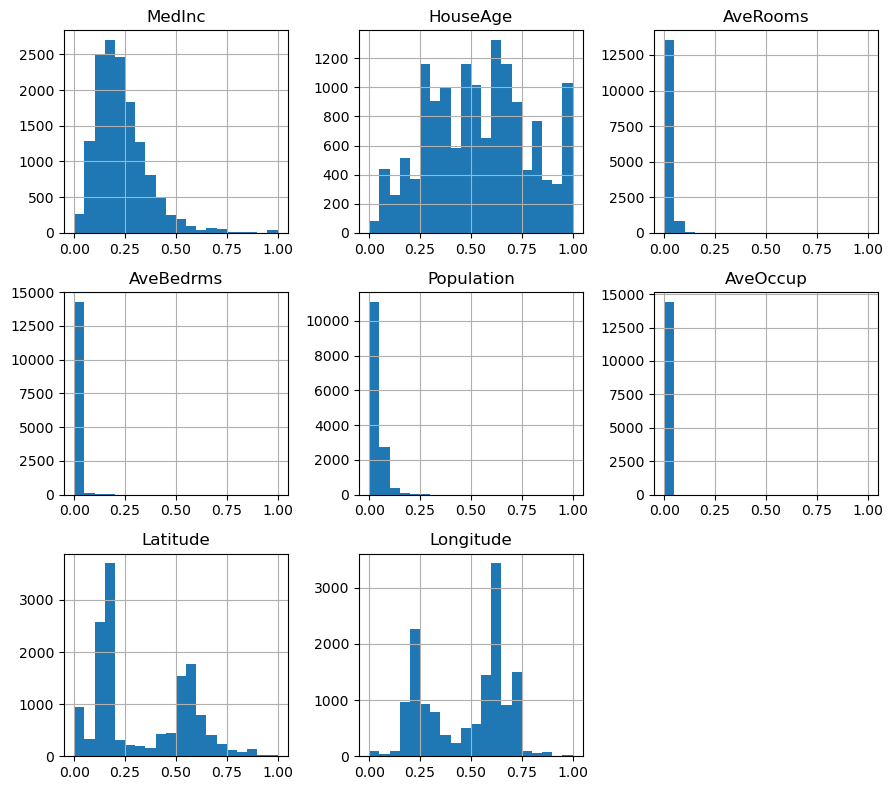

In [25]:
# Plot histograms of the features after scaling
X_train_scaled.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

The minimum and maximum values are different, but the shape of the distribution is similar.

## Mean Normalisation Pandas

In [26]:
# let's first learn the mean from the train set

means = X_train.mean(axis=0)
means

MedInc           3.866667
HouseAge        28.618702
AveRooms         5.423404
AveBedrms        1.094775
Population    1425.157323
AveOccup         3.040518
Latitude        35.630093
Longitude     -119.566647
dtype: float64

In [27]:
# let's now learn the min and max values, and the value range
# from the train set

ranges = X_train.max(axis=0)-X_train.min(axis=0)
ranges

MedInc           14.500200
HouseAge         51.000000
AveRooms        131.687179
AveBedrms        33.733333
Population    35679.000000
AveOccup        598.964286
Latitude          9.410000
Longitude        10.040000
dtype: float64

In [28]:
# Perform mean normalization (X_train and X_test)
X_train_scaled = (X_train - means) / ranges
X_test_scaled = (X_test - means) / ranges

In [29]:
# let's check the stats of the scaled data:

X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
std,0.13,0.25,0.02,0.01,0.03,0.01,0.23,0.20
min,-0.23,-0.54,-0.03,-0.02,-0.04,-0.00,-0.33,-0.48
25%,-0.09,-0.21,-0.01,-0.00,-0.02,-0.00,-0.18,-0.22
50%,-0.02,0.01,-0.00,-0.00,-0.01,-0.00,-0.15,0.11
75%,0.06,0.16,0.00,0.00,0.01,0.00,0.22,0.16
max,0.77,0.46,0.97,0.98,0.96,1.00,0.67,0.52


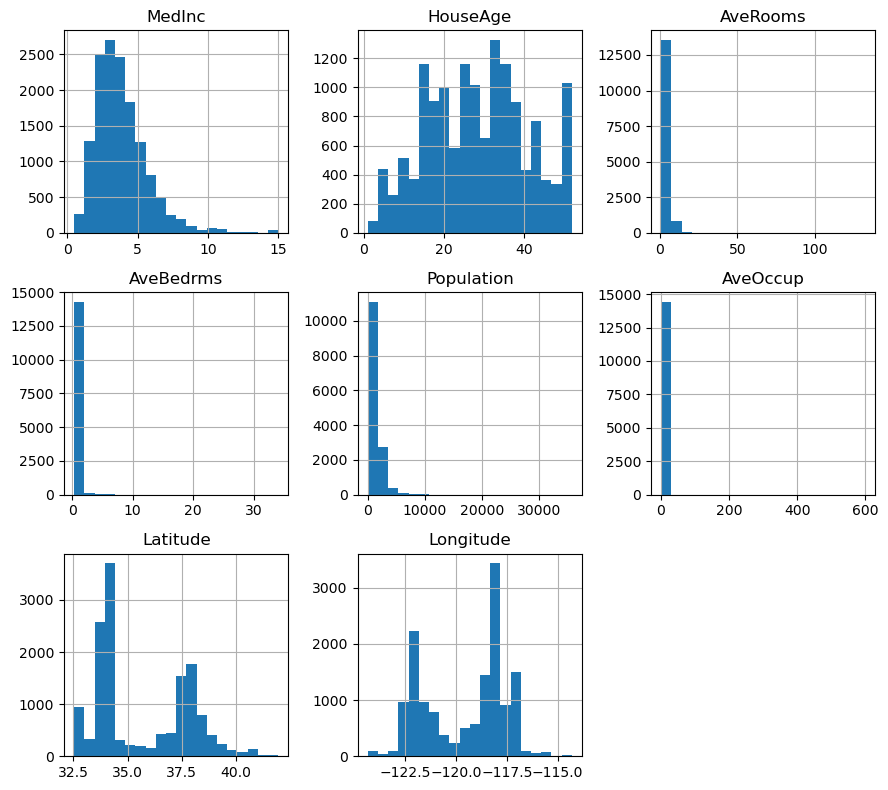

In [30]:
import matplotlib.pyplot as plt
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

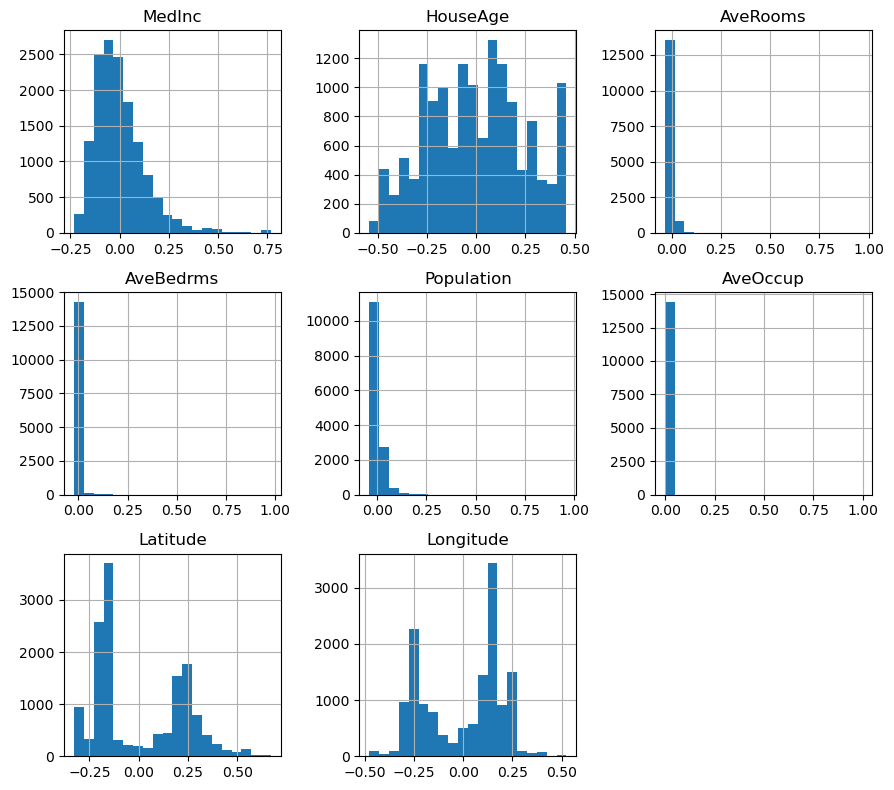

In [31]:
import matplotlib.pyplot as plt
# Plot histograms of the features after scaling
X_train_scaled.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

As expected, the mean of each variable, which were not centered at zero, is now around zero and the min and max values vary approximately between -1 and 1.

## Mean Normalisation Scikit-learn: work-around

We can implement mean normalisation by combining the use of 2 transformers.

In [32]:
# set up the StandardScaler to remove the mean
# without dividing by the standard deviation:

scaler_mean = StandardScaler(
    with_mean=True,
    with_std=False,
).set_output(transform="pandas")

In [33]:
# set up the robustscaler so that it does NOT remove the median
# but divides the sample by max()-min().

# To do this, set up the quantile range to 0 and 100
scaler_minmax = RobustScaler(
    with_centering=False,
    with_scaling=True,
    quantile_range=(0, 100),
).set_output(transform="pandas")

In [34]:
# fit the scalers to the train set, it will learn the parameters
scaler_mean.fit(X_train)
scaler_minmax.fit(X_train)

RobustScaler(quantile_range=(0, 100), with_centering=False)

In [35]:
# Transform train and test sets
X_train_scaled = scaler_minmax.transform(scaler_mean.transform(X_train))
X_test_scaled = scaler_minmax.transform(scaler_mean.transform(X_test))
# Now, X_train_scaled and X_test_scaled are scaled using both scalers

In [36]:
# let's check the stats of the scaled data:

X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
std,0.13,0.25,0.02,0.01,0.03,0.01,0.23,0.20
min,-0.23,-0.54,-0.03,-0.02,-0.04,-0.00,-0.33,-0.48
25%,-0.09,-0.21,-0.01,-0.00,-0.02,-0.00,-0.18,-0.22
50%,-0.02,0.01,-0.00,-0.00,-0.01,-0.00,-0.15,0.11
75%,0.06,0.16,0.00,0.00,0.01,0.00,0.22,0.16
max,0.77,0.46,0.97,0.98,0.96,1.00,0.67,0.52


In [37]:
# let's check the stats of the scaled data:
X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
std,0.13,0.25,0.02,0.01,0.03,0.01,0.23,0.20
min,-0.23,-0.54,-0.03,-0.02,-0.04,-0.00,-0.33,-0.48
25%,-0.09,-0.21,-0.01,-0.00,-0.02,-0.00,-0.18,-0.22
50%,-0.02,0.01,-0.00,-0.00,-0.01,-0.00,-0.15,0.11
75%,0.06,0.16,0.00,0.00,0.01,0.00,0.22,0.16
max,0.77,0.46,0.97,0.98,0.96,1.00,0.67,0.52


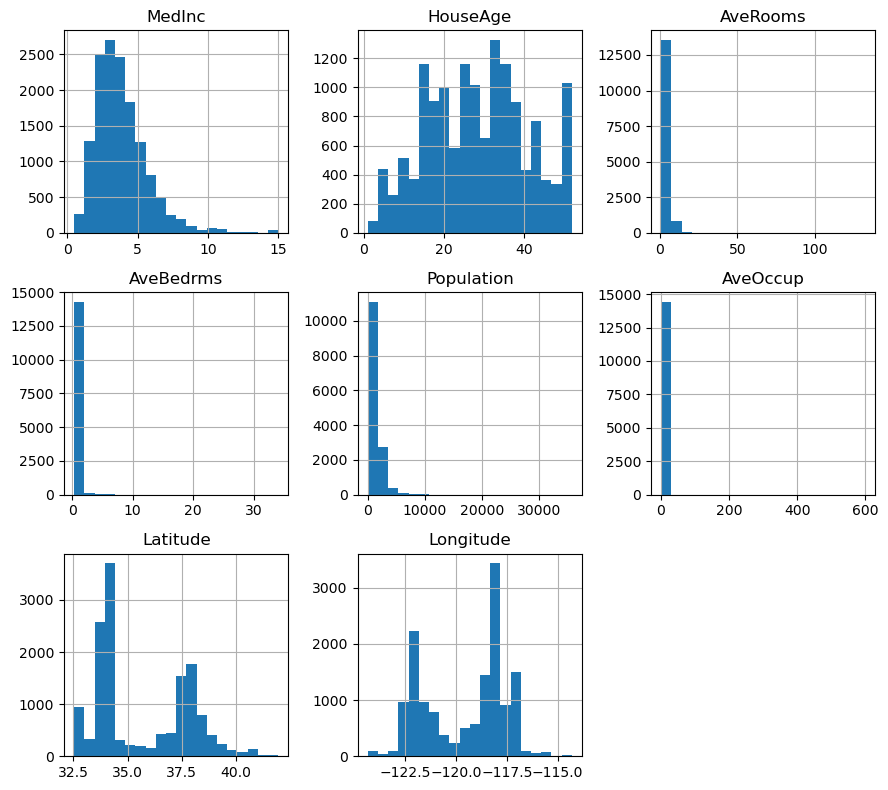

In [38]:
# Distribution before scaling:
import matplotlib.pyplot as plt
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

## MaxAbsScaling

The MaxAbsScaler from scikit-learn re-scales features to their absolute maximum value.

In [39]:
from sklearn.preprocessing import MaxAbsScaler
# Set up the scaler
scaler = MaxAbsScaler().set_output(transform="pandas")
# Fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)
# Transform the train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
# the scaler stores the maximum values of the features as learned from train set

scaler.max_abs_

array([1.50001000e+01, 5.20000000e+01, 1.32533333e+02, 3.40666667e+01,
       3.56820000e+04, 5.99714286e+02, 4.19500000e+01, 1.24350000e+02])

In this case, they were all positive values. But keep in mind that they can also take negative values, because we are looking for the absolute maximum.

In [41]:
# let's check the stats of the scaled data:

X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.26,0.55,0.04,0.03,0.04,0.01,0.85,-0.96
std,0.13,0.24,0.02,0.01,0.03,0.01,0.05,0.02
min,0.03,0.02,0.01,0.01,0.00,0.00,0.78,-1.00
25%,0.17,0.35,0.03,0.03,0.02,0.00,0.81,-0.98
50%,0.24,0.56,0.04,0.03,0.03,0.00,0.82,-0.95
75%,0.32,0.71,0.05,0.03,0.05,0.01,0.90,-0.95
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,-0.92


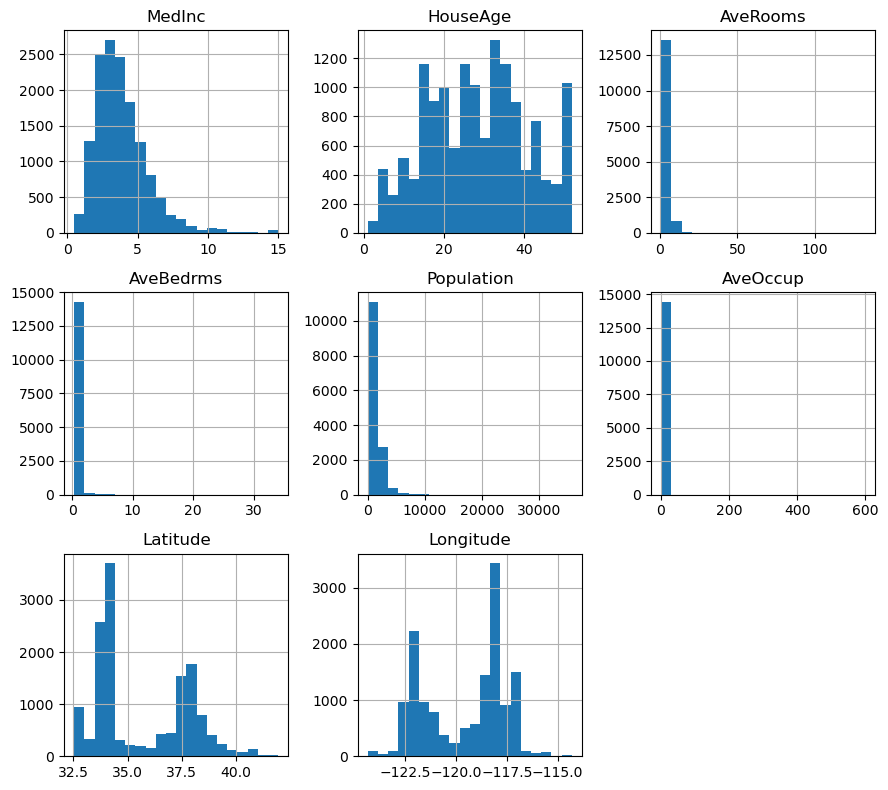

In [42]:
# Distribution before scaling:
import matplotlib.pyplot as plt
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

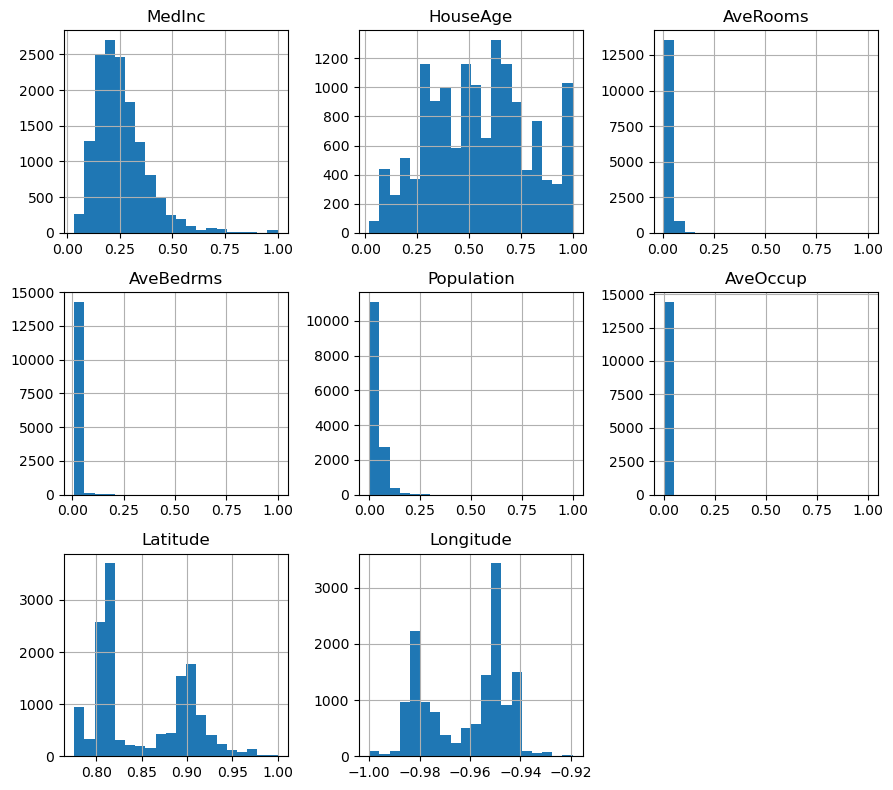

In [43]:
# Distribution after scaling:
# Plot histograms of the features after scaling
X_train_scaled.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

Variables are now scaled between -1 and 1.

## Centering + MaxAbsScaling

We can center the distributions at zero and then scale to its absolute maximum, as recommended by Scikit-learn by combining the use of 2 transformers.

In [44]:
# set up the StandardScaler to remove the mean
# without dividing by the standard deviation:
scaler_mean = StandardScaler(
    with_mean=True,
    with_std=False,
).set_output(transform="pandas")

# set up the MaxAbsScaler normally
scaler_maxabs = MaxAbsScaler().set_output(transform="pandas")

In [47]:
# Fit the scalers to the train set, it will learn the parameters
scaler_mean.fit(X_train)
# Fit the MaxAbsScaler to the transformed data (since centering will change the max values)
X_train_transformed = scaler_mean.transform(X_train)
scaler_maxabs.fit(X_train_transformed)
# Transform train and test sets
X_train_scaled = scaler_maxabs.transform(X_train_transformed)
X_test_scaled = scaler_maxabs.transform(scaler_mean.transform(X_test))


In [48]:
# let's check the stats of the scaled data:

X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
std,0.17,0.46,0.02,0.01,0.03,0.01,0.34,0.38
min,-0.30,-1.00,-0.04,-0.02,-0.04,-0.00,-0.49,-0.91
25%,-0.12,-0.38,-0.01,-0.00,-0.02,-0.00,-0.27,-0.42
50%,-0.03,0.01,-0.00,-0.00,-0.01,-0.00,-0.22,0.20
75%,0.08,0.30,0.00,0.00,0.01,0.00,0.33,0.30
max,1.00,0.85,1.00,1.00,1.00,1.00,1.00,1.00


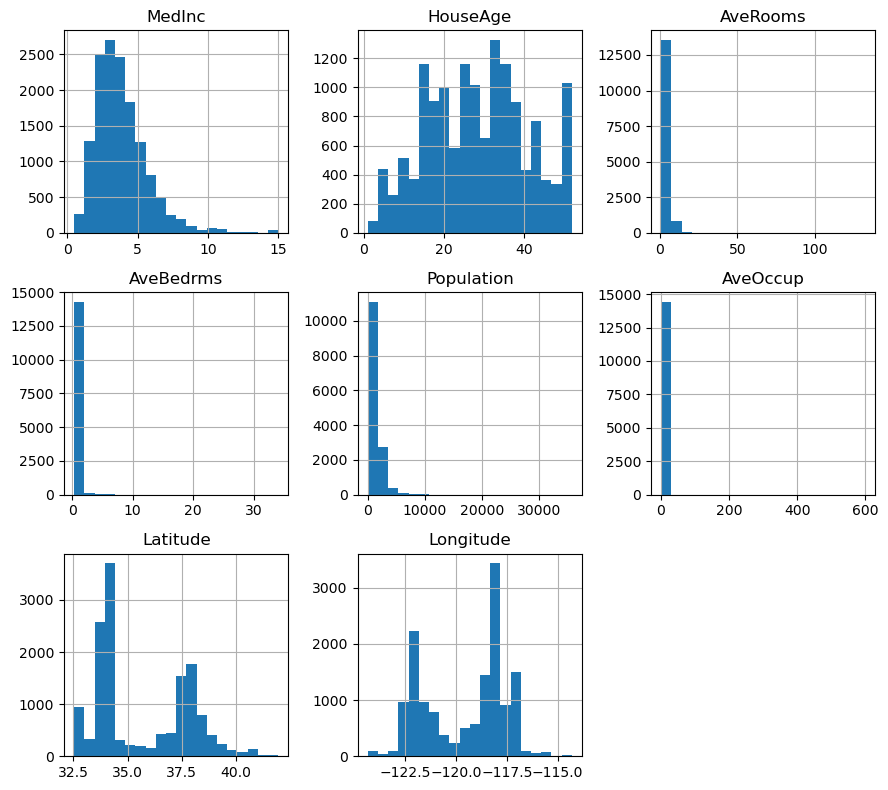

In [49]:
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

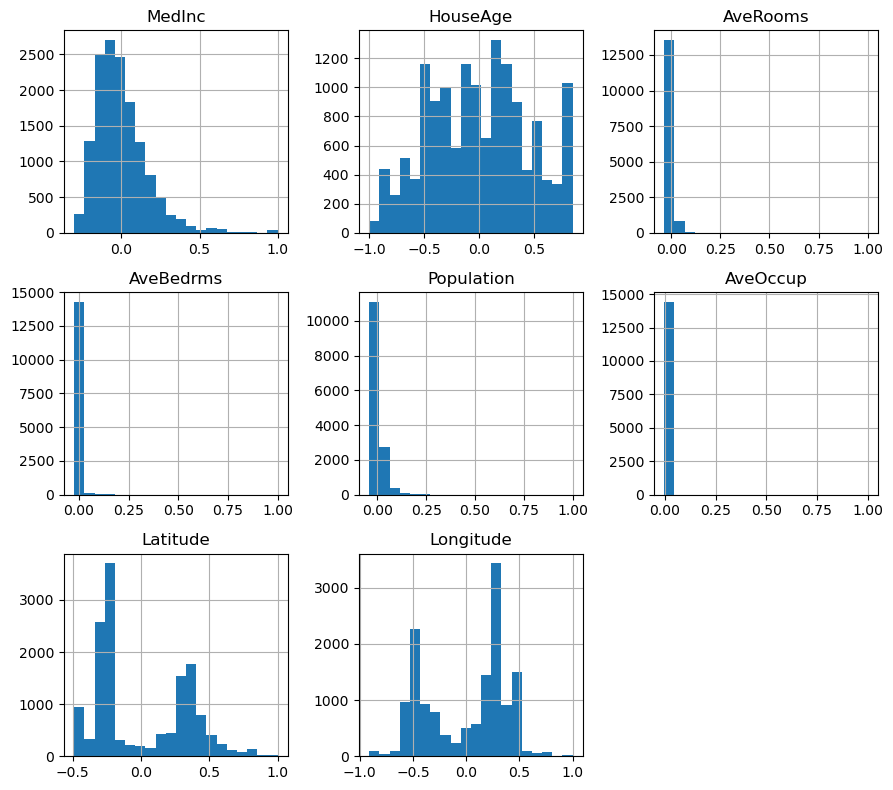

In [51]:
# Distribution after scaling:
# Plot histograms of the features after scaling
X_train_scaled.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

## RobustScaling

In [52]:
# set up the scaler
scaler = RobustScaler().set_output(transform="pandas")
# Fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)
# Transform the train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# the scaler stores the median values of the features as learned from train set
scaler.center_

array([ 3.53910000e+00,  2.90000000e+01,  5.22931763e+00,  1.04878049e+00,
        1.16500000e+03,  2.81635506e+00,  3.42600000e+01, -1.18490000e+02])

In [54]:
# the scaler stores the IQR values of the features as learned from train set

scaler.scale_

array([2.16550000e+00, 1.90000000e+01, 1.59537022e+00, 9.41284380e-02,
       9.40000000e+02, 8.53176853e-01, 3.78000000e+00, 3.80000000e+00])

In [55]:
# let's transform the returned NumPy arrays to dataframes for the rest of
# the demo

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [56]:
# let's check the stats of the scaled data:

X_train_scaled.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,0.15,-0.02,0.12,0.49,0.28,0.26,0.36,-0.28
std,0.87,0.66,1.43,4.81,1.22,8.05,0.57,0.53
min,-1.40,-1.47,-2.75,-7.60,-1.24,-2.42,-0.46,-1.54
25%,-0.45,-0.58,-0.49,-0.46,-0.41,-0.46,-0.09,-0.87
50%,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00
75%,0.55,0.42,0.51,0.54,0.59,0.54,0.91,0.13
max,5.29,1.21,79.80,350.77,36.72,699.62,2.03,1.10


Note the median is now 0 for all variables.

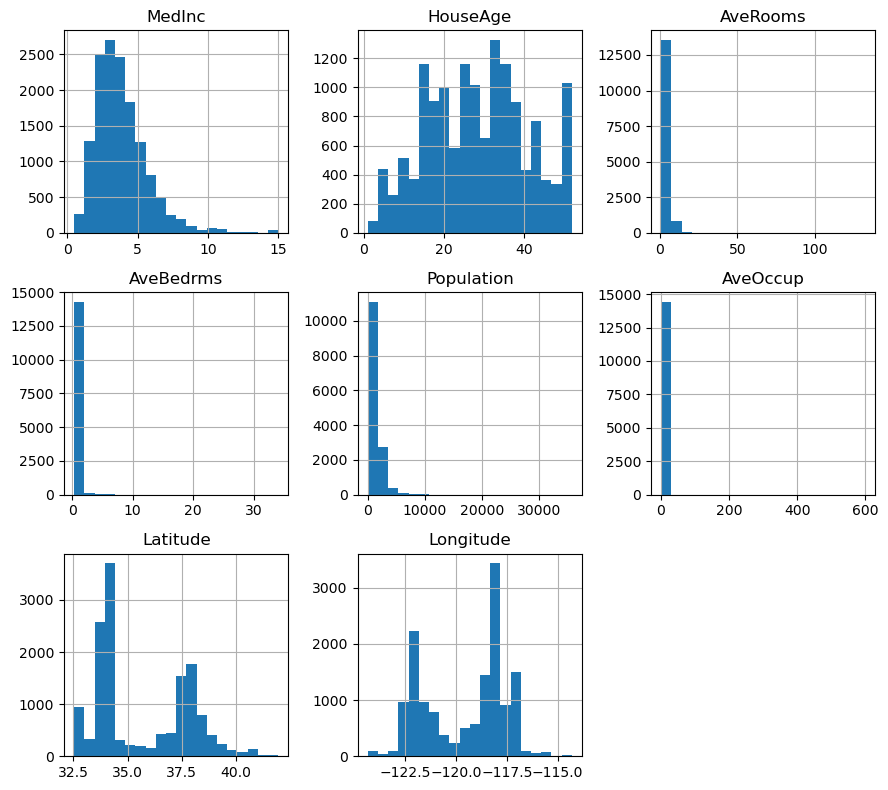

In [57]:
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

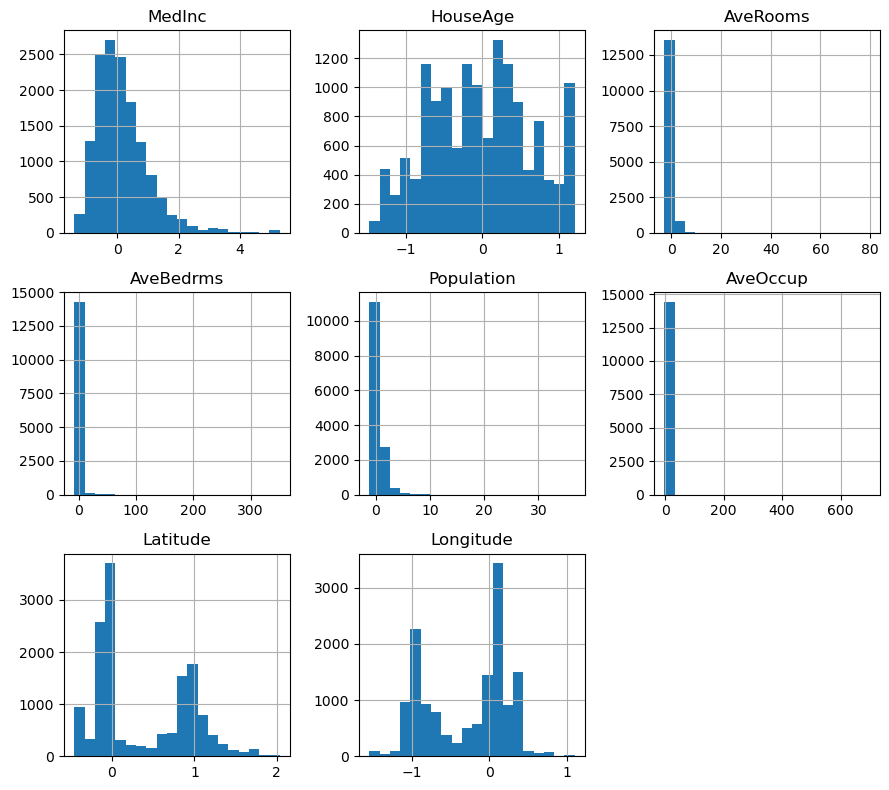

In [58]:
# Distribution after scaling:
# Plot histograms of the features after scaling
X_train_scaled.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

The variables were centered at the median values.

## Scaling to l1

In [59]:
# set up the scaler
scaler = Normalizer(norm='l1').set_output(transform="pandas")
# Fit the scaler, this procedure does NOTHING since Normalizer doesn't learn␣parameters
scaler.fit(X_train)
# Transform the train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
# let's calculate the norm for each observation (feature vector)
# original data

np.round(np.linalg.norm(X_train, ord=1, axis=1), 1)

array([ 411.8, 1049.1, 1573.6, ...,  903.1, 1251. , 1197.2])

In [61]:
# let's calculate the norm for each observation (feature vector)
# scaled data

np.round(np.linalg.norm(X_train_scaled, ord=1, axis=1), 1)

array([1., 1., 1., ..., 1., 1., 1.])

Now, each feature vector has a l1 norm of 1.

In [62]:
# let's look at the individual values of the variables in the original data

X_train_scaled.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,0.003307,0.025618,0.004845,0.000980,0.829530,0.002471,0.030689,-0.102560
std,0.003101,0.021863,0.006238,0.001385,0.115177,0.002263,0.020812,0.068250
min,0.000072,0.000209,0.000147,0.000028,0.016782,0.000163,0.000930,-0.691357
25%,0.001554,0.011168,0.002548,0.000549,0.795538,0.001473,0.018314,-0.121284
50%,0.002535,0.020402,0.003785,0.000772,0.854378,0.002075,0.026044,-0.087644
75%,0.004005,0.033935,0.005554,0.001074,0.899395,0.002862,0.036334,-0.062273
max,0.065525,0.236108,0.329271,0.084637,0.994950,0.119789,0.206662,-0.003274


In [64]:
# Distribution before scaling:
# Fit the scaler, this procedure does NOTHING since Normalizer doesn't learn␣parameters
scaler.fit(X_train)
# Transform the train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

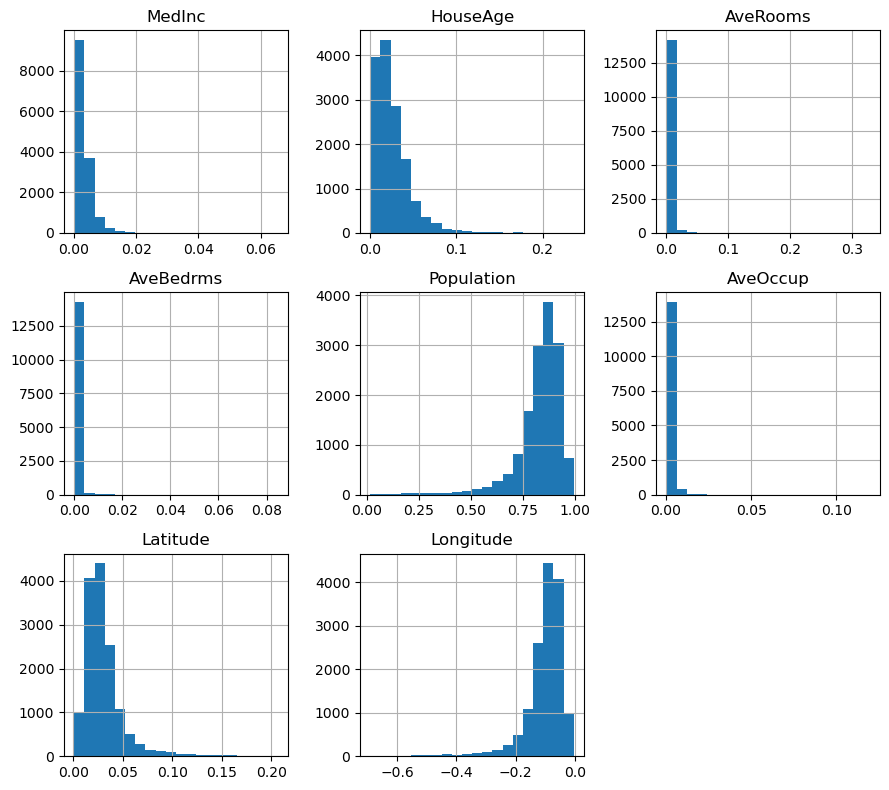

In [65]:
# Distribution after scaling:
# Plot histograms of the features after scaling
X_train_scaled.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

See how this normalisation changes the distribution of the original variable quite dramatically.

## Scaling to l2

In [67]:
# set up the scaler
scaler = Normalizer(norm='l2').set_output(transform="pandas")
# Fit the scaler, this procedure does NOTHING as Normalizer doesn't learn␣parameters
scaler.fit(X_train)
# Transform the train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
# let's calculate the norm for each observation (feature vector)
# original data

np.round( np.linalg.norm(X_train, ord=2, axis=1), 1)

array([ 236. ,  846.8, 1392.6, ...,  716.1, 1059.7, 1031.1])

In [69]:
# let's calculate the norm for each observation (feature vector)
# scaledl data

np.round( np.linalg.norm(X_train_scaled, ord=2, axis=1), 1)

array([1., 1., 1., ..., 1., 1., 1.])

In [70]:
X_train_scaled.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,0.004258,0.033325,0.006370,0.001292,0.978428,0.003174,0.039616,-0.132217
std,0.005068,0.036131,0.011609,0.002634,0.074459,0.003599,0.036169,0.118785
min,0.000072,0.000212,0.000148,0.000028,0.024116,0.000164,0.000935,-0.957531
25%,0.001745,0.012462,0.002841,0.000610,0.986614,0.001650,0.020339,-0.150302
50%,0.002983,0.023740,0.004415,0.000900,0.993908,0.002423,0.030343,-0.101977
75%,0.004940,0.041784,0.006860,0.001330,0.997267,0.003535,0.045020,-0.069048
max,0.113007,0.392072,0.687806,0.176795,0.999994,0.141353,0.295699,-0.003291


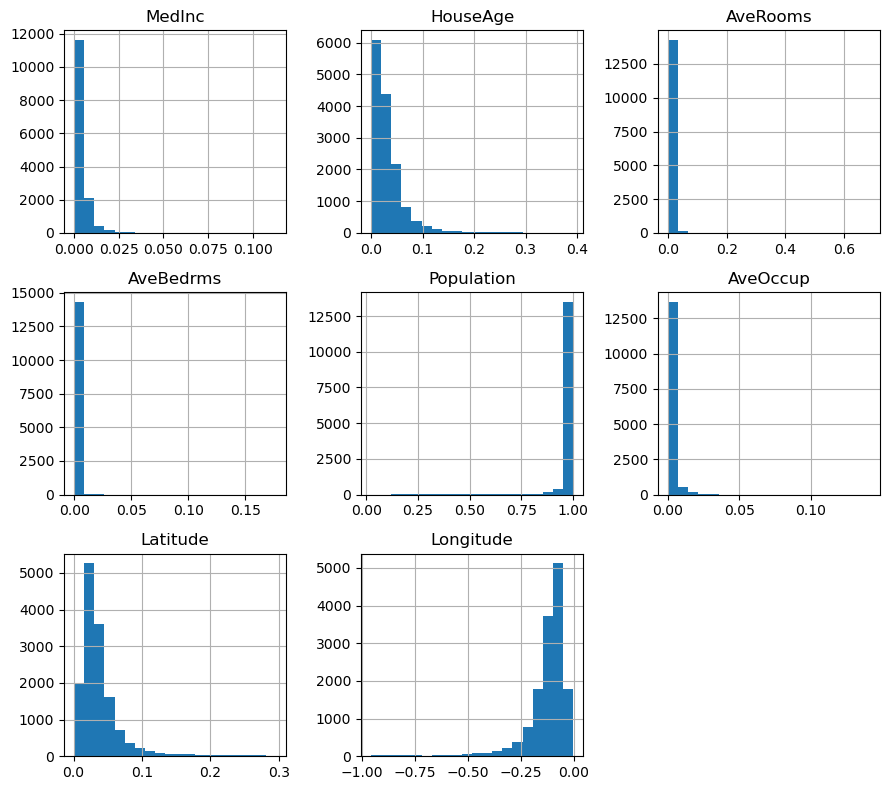

In [71]:
# Distribution after scaling:
# Plot histograms of the features after L2 scaling
X_train_scaled.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()

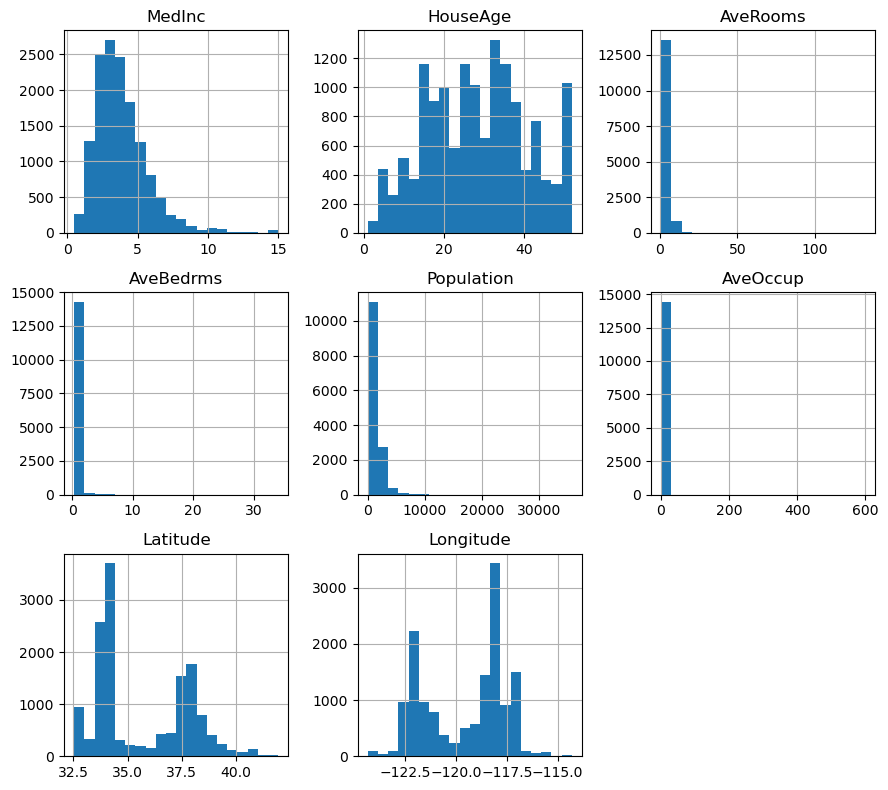

In [72]:
# Plot histograms of the features before scaling
X_train.hist(bins=20, figsize=(9, 8))
plt.tight_layout()
plt.show()